In [41]:
import numpy as np
import matplotlib.pyplot as plt

In [42]:
# CONSTANTS
bit_widths = [2, 3, 4, 8]
SEED = 24
SCHEMES = {
    "No Zero Point Offset":          dict(sym=True),                   # no Z
    "Zero Point w/ Round":   dict(sym=False, z_round=True),    # Z rounded to an int
    "Zero Point w/o Round": dict(sym=False, z_round=False),   # Z left as a float
}

In [43]:
def rtn_quant(x: np.ndarray, bitwidth: int, z_round: bool = False, signed: bool = True, sym: bool = False):
    q_min, q_max = (
        (-(2 ** (bitwidth - 1)), 2 ** (bitwidth - 1) - 1)
        if signed
        else (0, 2**bitwidth - 1)
    )

    if sym:
        # symmetric: real 0 maps to int 0, scale set by the largest magnitude
        S = np.abs(x).max() / q_max
        Z = 0
    else:
        # asymmetric: stretch [x.min, x.max] onto [q_min, q_max]
        S = (x.max() - x.min()) / (q_max - q_min)
        Z = q_min - (x.min()/S)
        if z_round:
            Z = np.round(Z)

    # clip to the representable int range
    q = np.clip(np.round(x/S + Z), q_min, q_max)
    return q, S, Z

In [44]:
def rtn_dequant(x: np.ndarray, S, Z, sym: bool = False):
    return S * x if sym else S * (x - Z)

In [45]:
def mse(pred: np.ndarray, target: np.ndarray):
    return np.mean(np.square(pred - target))

In [46]:
def run_exp(distribution: str, seed: int = SEED):
    rng = np.random.default_rng(seed)

    if distribution == "nonzero floats":  # range away from 0
        X = rng.uniform(90, 110, 10000)

    elif distribution == "gaussian floats":  # weight-like, has negatives
        X = rng.normal(0, 1, 10000)

    elif distribution == "pruned floats":  # exact zeros included
        X = rng.normal(0, 1, 10000)
        X[rng.random(10000) < 0.5] = 0.0

    else:
        raise ValueError(f"unknown distribution: {distribution}")

    res = {b: {} for b in bit_widths}
    for b in res:
        # quant -> dequant round for every scheme, on the same X
        for name, kwargs in SCHEMES.items():
            q, S, Z = rtn_quant(X, b, **kwargs)
            xhat = rtn_dequant(q, S, Z, sym=kwargs["sym"])
            res[b][name] = {"mse": mse(xhat, X), "bias": np.mean(xhat - X)}

    return res

In [47]:
distributions = ["nonzero floats", "gaussian floats", "pruned floats"]
seeds = range(SEED, SEED + 20)

# results[v][b][name][metric] = mean over seeds
# bias uses mean |bias|: its sign flips between seeds, so a plain mean would cancel it out
results = {}
for d in distributions:
    runs = [run_exp(d, seed) for seed in seeds]
    results[d] = {
        b: {
            name: {
                "mse": np.mean([r[b][name]["mse"] for r in runs]),
                "bias": np.mean([abs(r[b][name]["bias"]) for r in runs]),
            }
            for name in SCHEMES
        }
        for b in bit_widths
    }

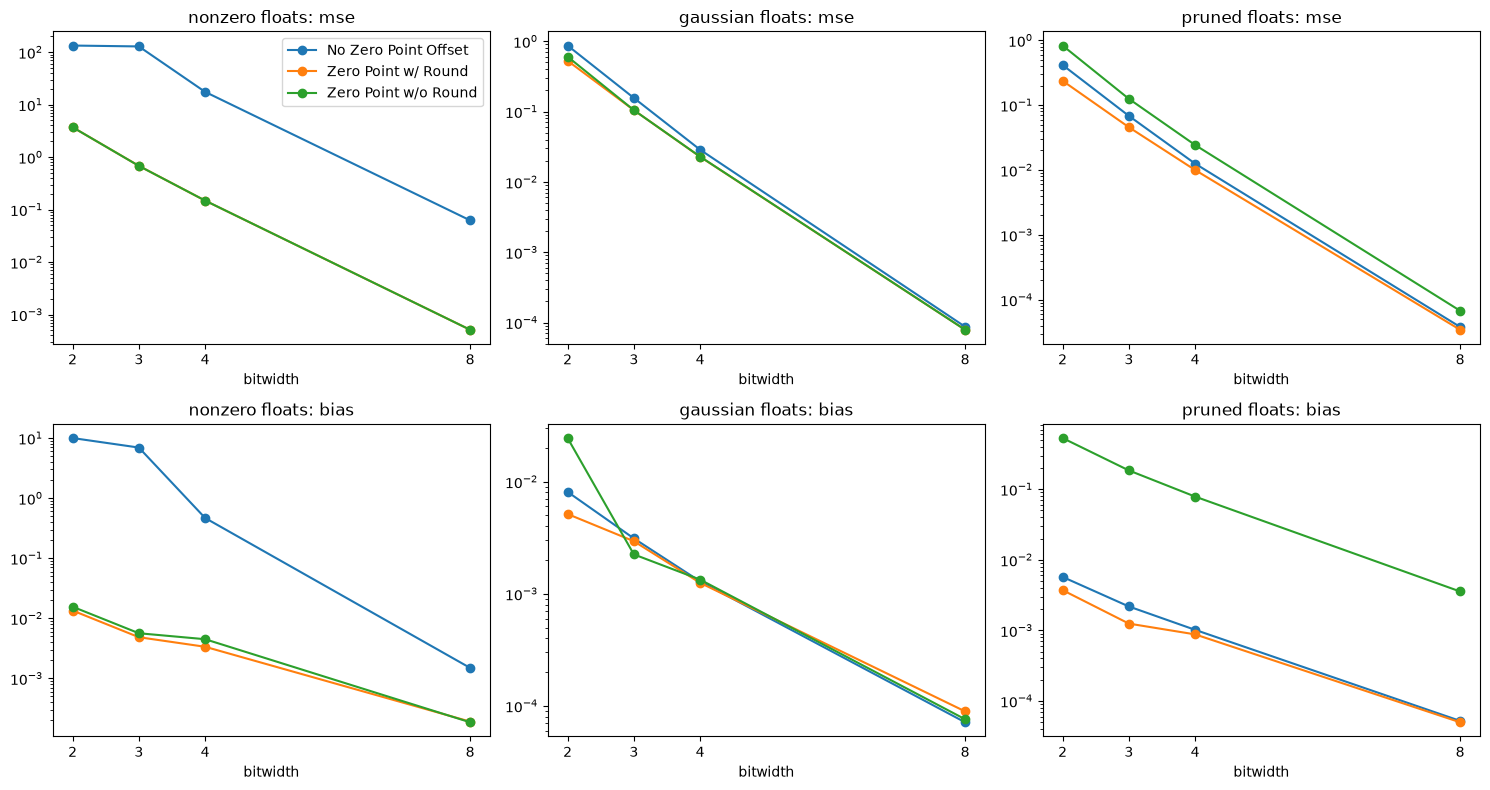

In [52]:
# rows = metric, cols = distribution; scales differ, so don't share axes
metrics = ["mse", "bias"]
fig, axes = plt.subplots(len(metrics), len(distributions), figsize=(15, 8))
for row, metric in zip(axes, metrics):
    for ax, d in zip(row, distributions):
        for name in SCHEMES:
            ax.plot(bit_widths, [results[d][b][name][metric] for b in bit_widths], marker="o", label=name)
        ax.set(title=f"{d}: {metric}", xlabel="bitwidth", yscale="log", xticks=bit_widths)
axes[0, 0].legend()
plt.tight_layout()
plt.show()